# Global Conflict Analysis: Descriptive Insights from 1979–2021
## Third Notebook: Objective

Building on the descriptive and exploratory analyses conducted in the first two notebooks, this third notebook focuses on visualization and synthesis of insights from the global conflict events dataset.

The primary goal is to create an interactive dashboard summarizing key metrics and patterns in conflict events from 1979–2021, facilitating intuitive exploration of temporal trends, regional and country-level distributions, conflict severity, and media coverage.

In addition to visualization, this notebook provides interpretations of observed patterns, highlights preliminary insights that could inform policymakers, humanitarian agencies, and researchers, and outlines potential avenues for further, more detailed analyses, including predictive modeling, clustering of conflict patterns, and scenario-based impact assessments.

**Author**: J-F Jutras  
**Date**: November 2025  
**Dataset**: Global Conflict Events Dataset – Kaggle

## 3.1-Data Loading

In [ ]:
import pandas as pd
import os
import kagglehub

# Download latest version
path = kagglehub.dataset_download("vladproex/gdelt-conflict-events-1979-2021")

print("Path to dataset files:", path)

In [ ]:
#Import original file
dataset_dir = '/kaggle/input/gdelt-conflict-events-1979-2021'
csv_path = os.path.join(dataset_dir, 'gdelt_conflict_1_0.csv')

df_original = pd.read_csv(csv_path)

print(df_original.head())

## 3.2-Conflict Types and Temporal Evolution

**Conflict Type Composition**  

The dataset contains detailed event descriptions categorized into four root conflict types:

- **ASSAULT:** 13 subtypes  
- **COERCE:** 12 subtypes  
- **FIGHT:** 7 subtypes  
- **UNCONVENTIONAL MASS VIOLENCE:** 3 subtypes  

This highlights the internal diversity of each category and provides the basis for comparing their severity profiles.

**Temporal Evolution (1979–2021)**  
- Event counts gradually increased until **2014–2016**, followed by a decline.  
- **COERCE** remains the most frequent conflict category throughout the period.  
- **UNCONVENTIONAL MASS VIOLENCE** shows the fastest relative growth from its baseline.  
- Average severity slightly worsens over the period (≈ –8.28 → –8.44 on the Goldstein Scale), with the most severe years occurring between **2012–2016**.


**Line Chart - Temporal Trends by Total Number of Events and Type of Conflict (1979-2021)**

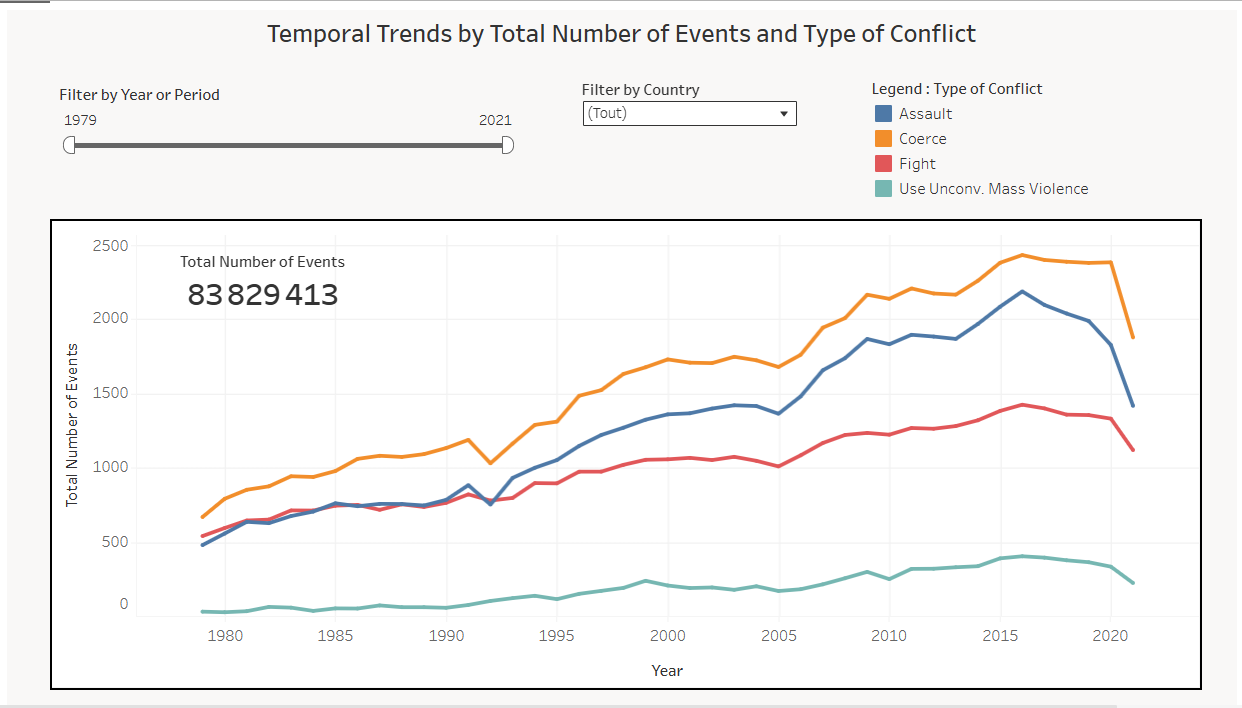


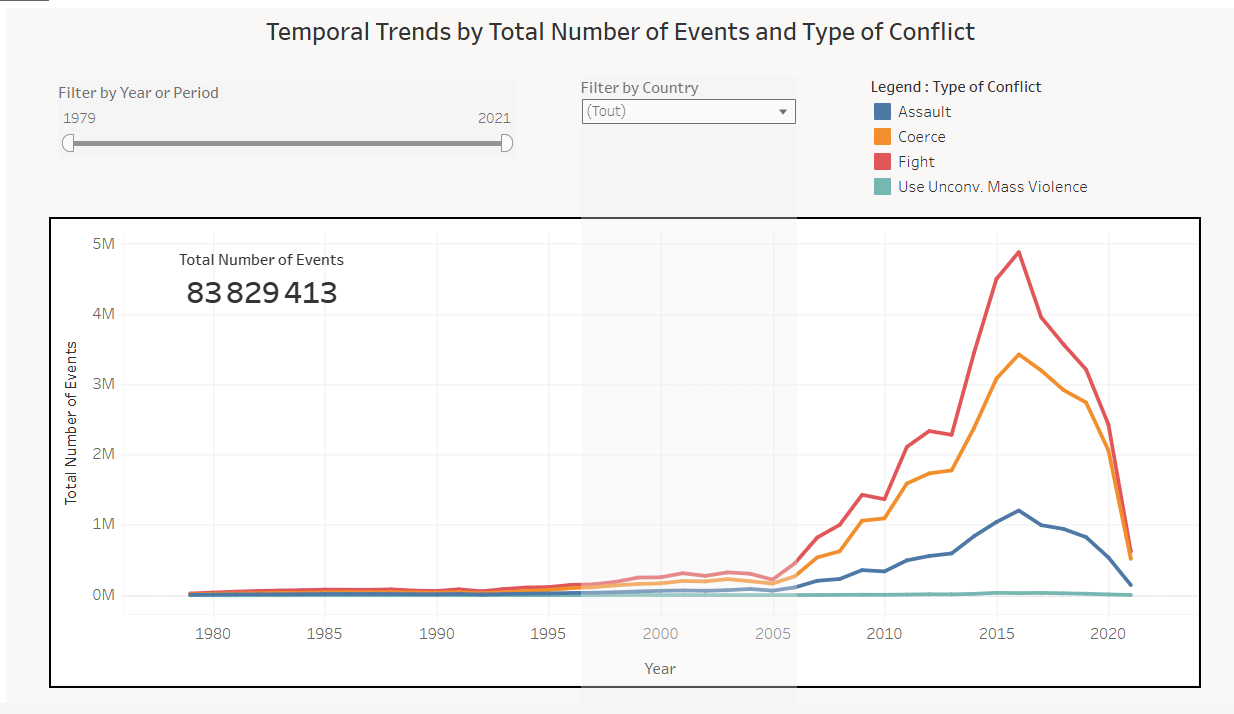

**Line Chart - Temporal Trends by Total Number of Events and Type of Conflict (1979-1989)**

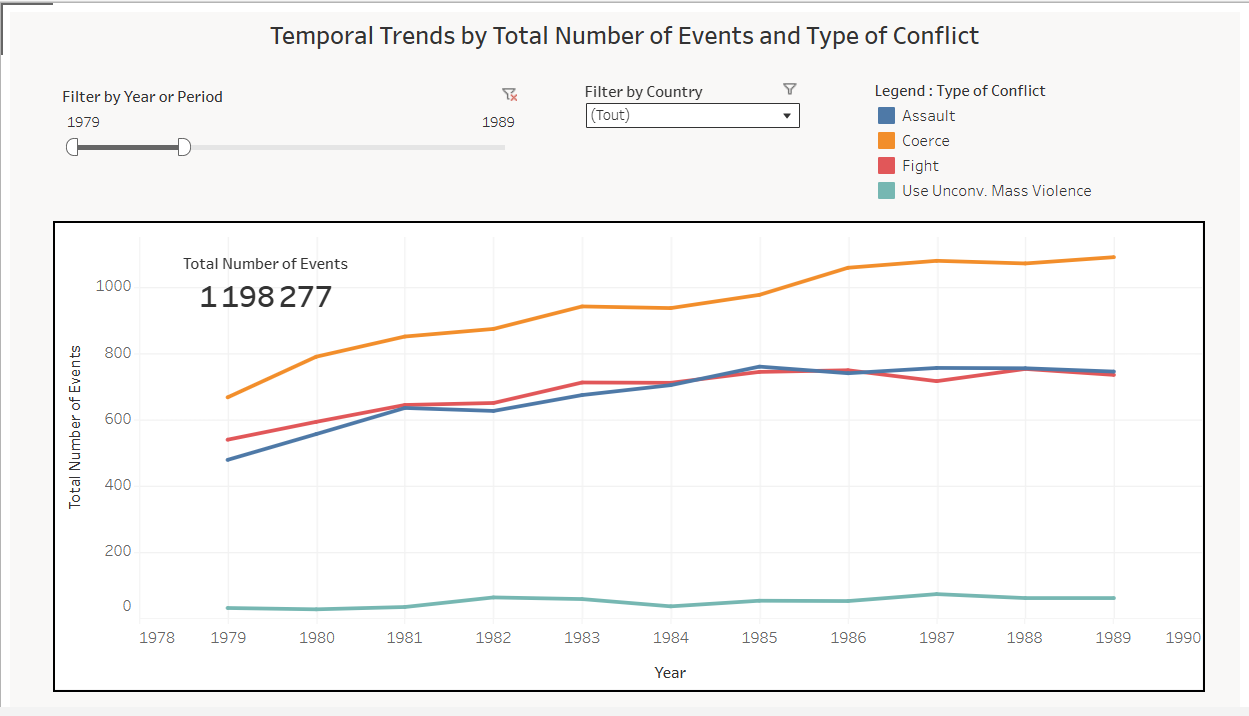
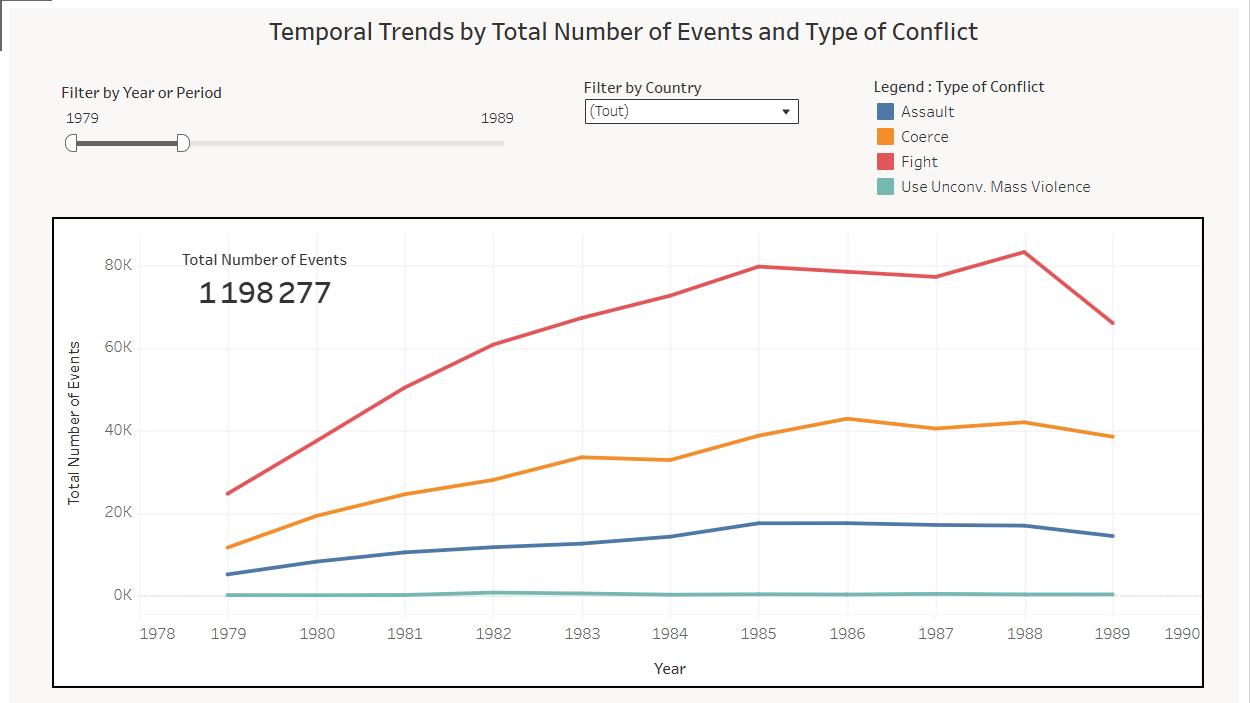
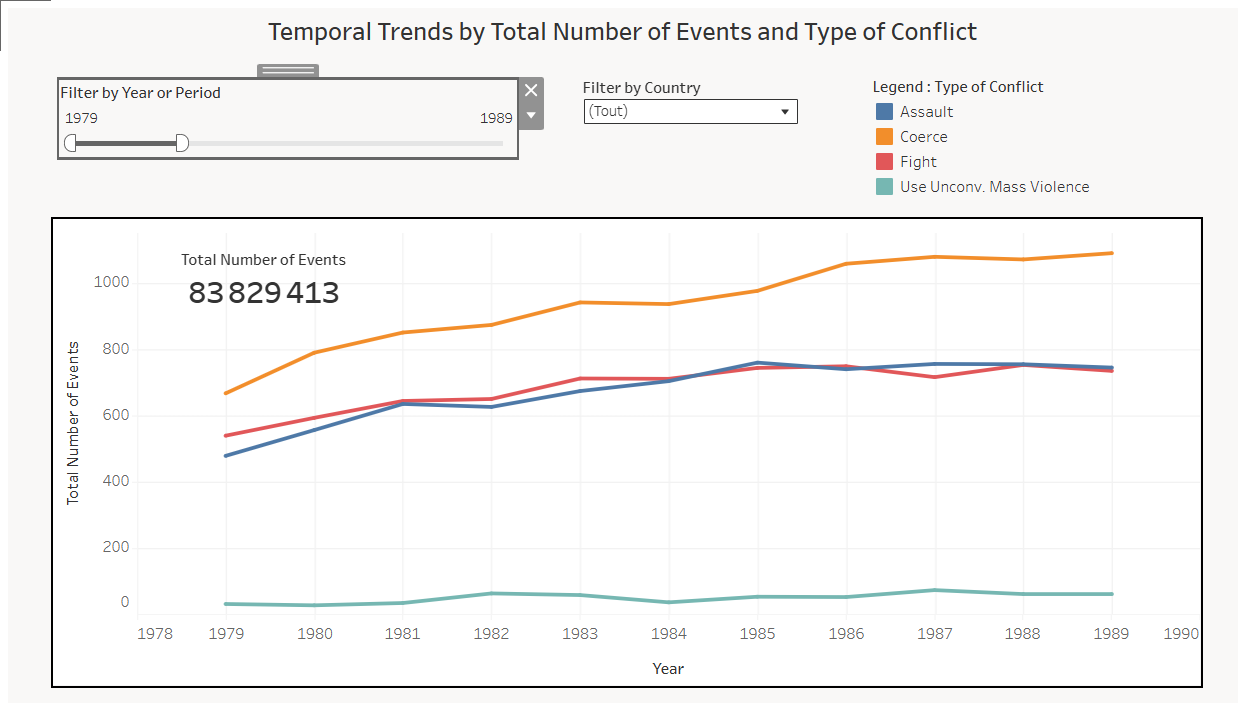

**Line Chart - Temporal Trends by Total Number of Events in Argentina and Type of Conflict (2000-2006)**

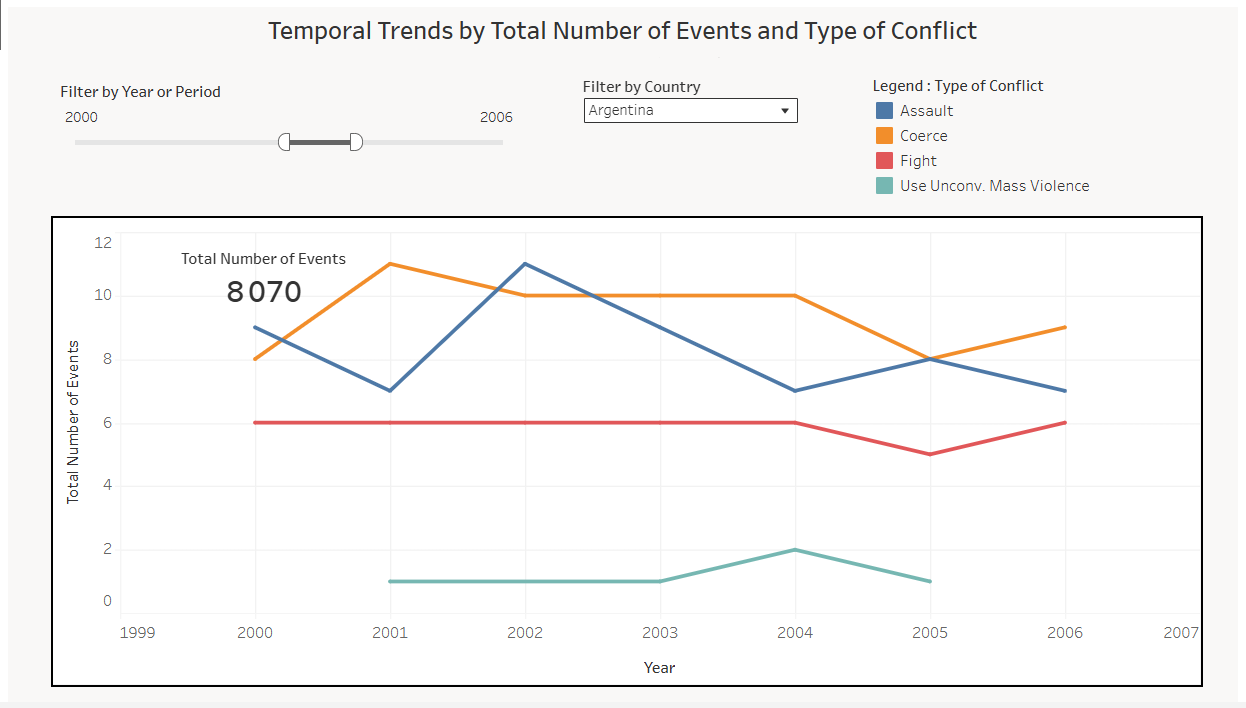


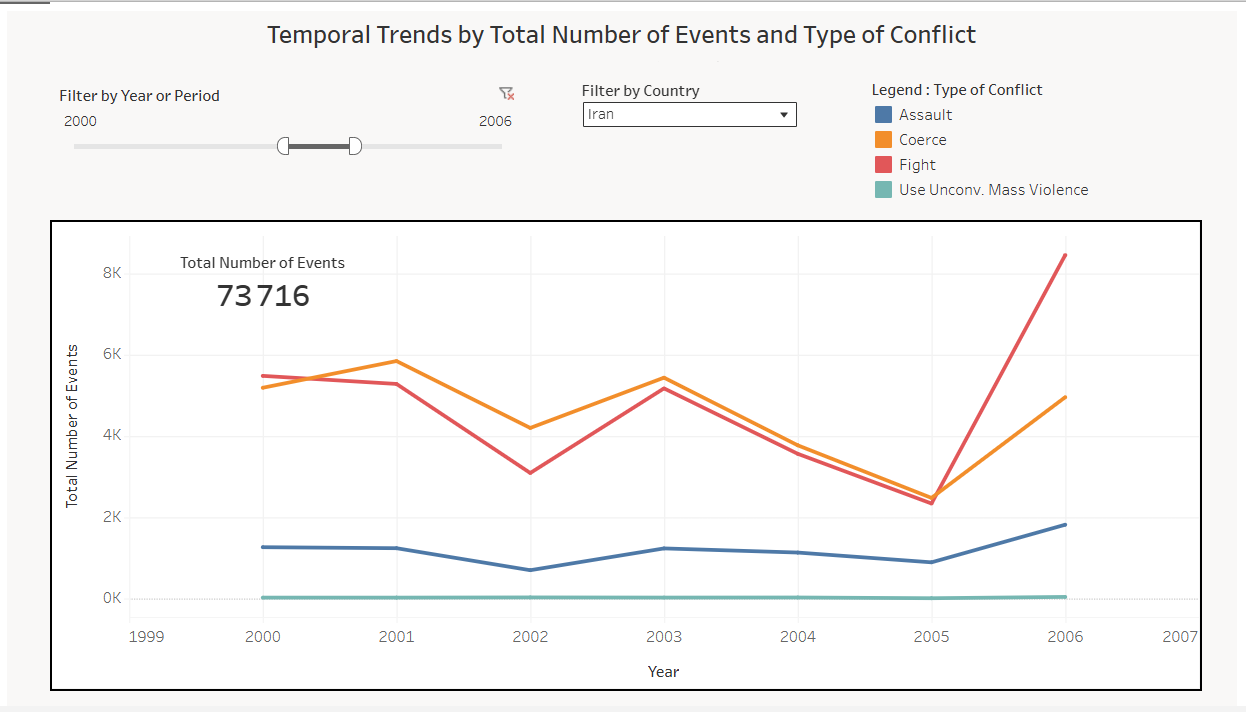

**Visualization Choice and Rationale**

A line chart was selected to represent the temporal evolution of conflict events across the four main conflict types. This visualization provides an intuitive way to compare trends over time, highlighting long-term increases, peaks, and declines. The use of multiple lines on a single timeline makes it easy to identify differences in frequency dynamics between categories such as COERCE, FIGHT, ASSAULT, and UNCONVENTIONAL MASS VIOLENCE.

The chart’s simplicity is intentional: it offers a clean, uncluttered view of macro-level patterns without overwhelming the user with operational details. By integrating filters such as year ranges, specific periods, or country selection, the dashboard becomes a flexible exploration tool. These interactive elements enable users to move seamlessly from global patterns to regional or country-specific views, providing a bridge between high-level trends and more granular observations.

**Next Steps : Suggestions form Deeper Temporal Analysis**

| Next Step | Method | Insights Provided | Value for Decision-Makers |
|-----------|--------|-----------------|--------------------------|
| **1. Identify Structural Breaks and Regime Shifts in Conflict Activity** | - Use rolling averages and rolling standard deviations.<br>- Apply structural break tests.<br>- Analyze conflict-type-specific breakpoints to identify which categories drive major shifts. | - Characterization of escalation, stabilization, or decline phases.<br>- Exact years where global conflict dynamics changed.<br>- Identification of type-specific temporal regimes. | - Supports early-warning systems and escalation forecasting.<br>- Enables contextual linking of breakpoints to geopolitical events.<br>- Facilitates scenario planning and strategic preparedness. |
| **2. Analyze Country- and Region-Specific Temporal Trajectories** | - Construct region-level and country-level time series.<br>- Cluster temporal trajectories using clustering techniques (k-means, hierarchical methods, etc.).<br>- Compare volatility, persistence, and long-term evolution. | - Regions that drive global peaks and declines.<br>- Countries with stable vs. volatile conflict dynamics.<br>- Groups of states following similar long-term patterns. | - Helps prioritize humanitarian and security interventions.<br>- Identifies chronic escalation zones vs. emerging hotspots.<br>- Provides actionable context for regional and bilateral policy design. |
| **3. Model Drivers of Temporal Change Using Multivariate Analysis** | - Integrate external datasets (GDP, governance indices, displacement data, etc.).<br>- Use panel regression or time-varying correlation analysis.<br>- Test which variables align with escalation or de-escalation periods. | - Economic, political, and social factors linked to conflict surges.<br>- Sensitivity of different conflict types to specific drivers.<br>- Early indicators to monitor for shifts in conflict dynamics. | - Enables evidence-based policy action.<br>- Supports strategic planning and risk mitigation.<br>- Helps target interventions addressing root causes of instability. |


## 3.3-Media Coverage and Conflict Severity

**Global Analysis**

At the global level, descriptive statistics show that media coverage is largely **independent of conflict severity** (GoldsteinScale). Mean and median mention counts remain similar across severity levels, indicating that more severe events do not systematically receive more attention.

Spearman correlations between severity and media coverage measures (AvgNumMentions, SumNumMentions) are **very weak** (≈ –0.02 to –0.05), confirming the absence of a meaningful relationship. Conversely, media coverage exhibits **strong positive correlations** with event volume (SumEvents, TotalEvents), demonstrating that **coverage is primarily driven by quantity**, not intensity.

**Continental Analysis**

Examining the data at the continental level (Africa, Asia, Europe, North America, South America, Oceania, Antarctica) confirms the global pattern.  

Across all continents:

- **Severity vs. coverage correlations remain negligible**  
- **Coverage maintains a strong association with event volume**  
- **Tone correlations remain weakly negative (to be interpreted cautiously)**

No continent departs from this overarching dynamic: **conflict severity does not predict media attention at a macro level**, regardless of regional context.

**Regional Analysis**

A more granular breakdown using regional classifications (e.g., Middle East, Far East, Indian Subcontinent, Southern Africa, etc.) further validates these findings.

While correlations between severity and coverage remain **minimal**, significant **differences in average coverage** exist across regions.  

A Welch ANOVA confirms these differences: **F(18, 176,413) = 72.88, p < 0.001**

Post-hoc Games–Howell tests reveal which regions differ most, with examples including:

- Indian Subcontinent  
- Far East  
- Southern Africa  

Despite these variations, the fundamental pattern persists: **media attention follows event volume rather than severity**, even at the regional scale.

**Choropleth Map - Weighted Media Visibility by Country**

To highlight disparities in how countries are covered by the media, we introduced a derived indicator: **Media Coverage per Normalized Event** (`AvgNumMentions * NormalizedEvents1000`). Because `NormalizedEvents1000` is calculated at the yearly level, this metric can only be interpreted on a **year-by-year basis**, which is methodologically appropriate given the structure of the data. Despite this constraint, the indicator remains highly useful: by adjusting media mentions relative to each country’s event volume, it enables clearer cross-country comparisons and reveals which countries receive disproportionately high or low media attention relative to their conflict activity.

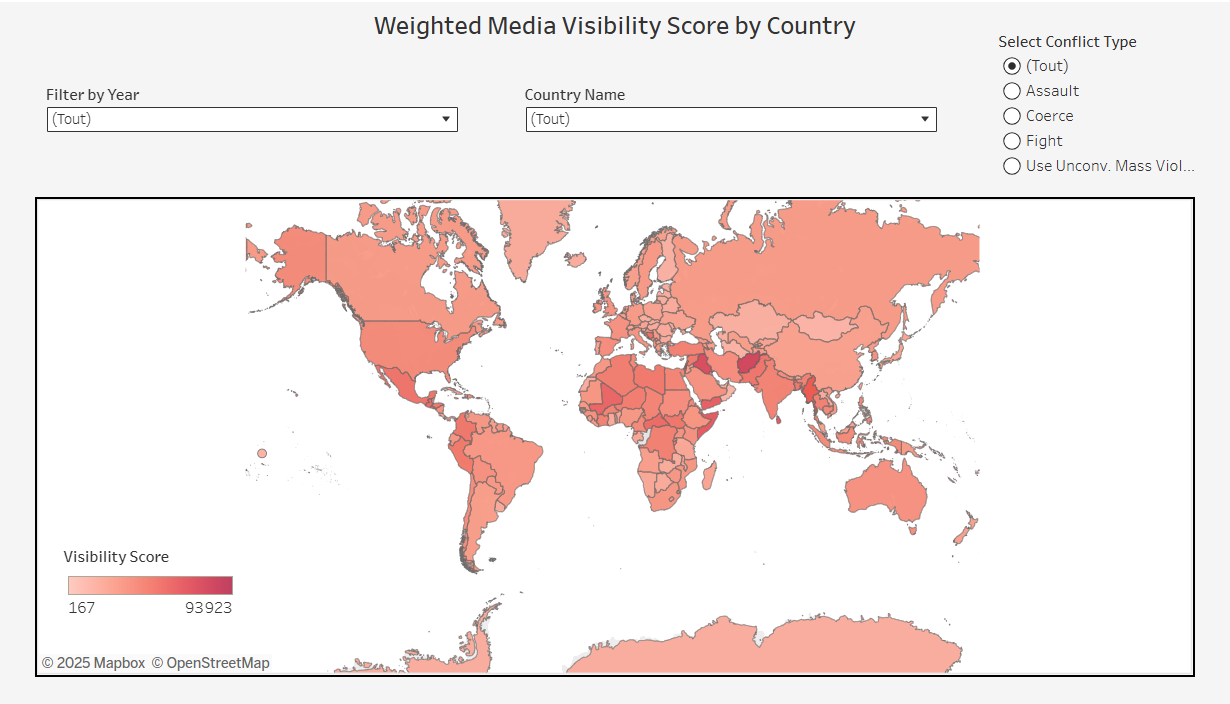

**Choropleth Map - Weighted Media Visibility by Country in 2015**

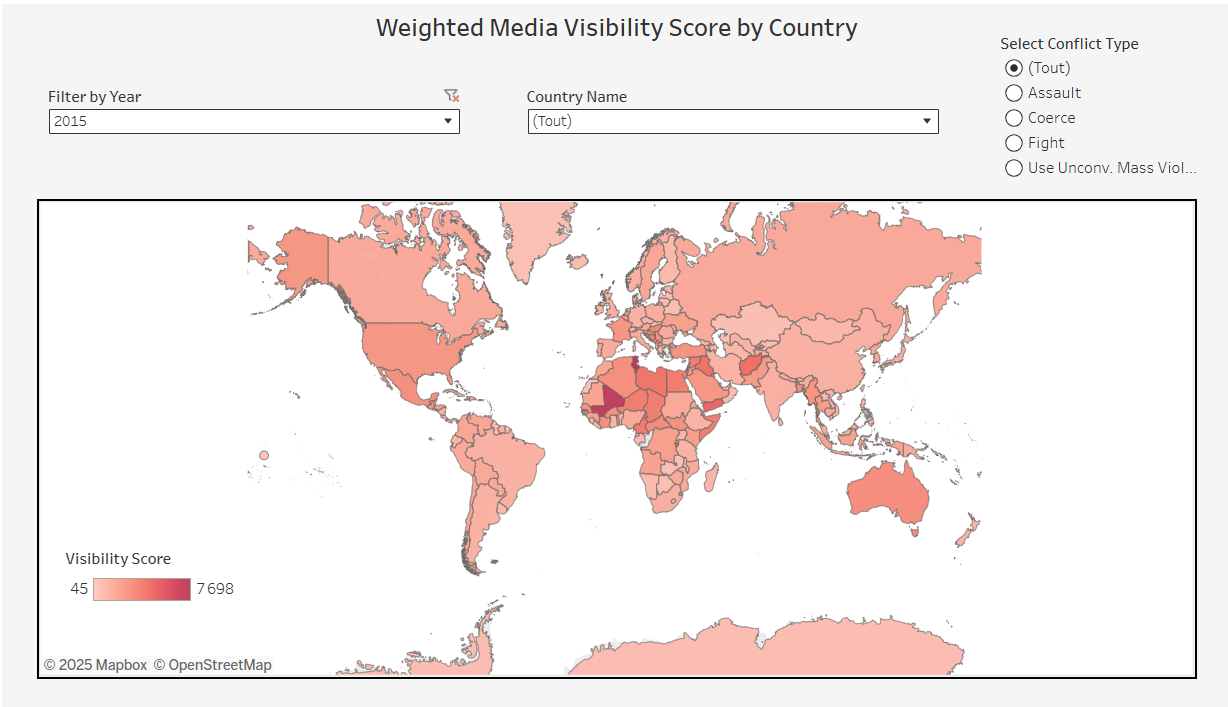

In addition to the main dashboard visualizations, a complementary indicator (`AvgNumMentions / NormalizedEvents1000`) was computed to identify which countries receive the highest relative media coverage. Although not included as an official visualization, this exploratory metric provided a quick way to highlight countries that attract disproportionately high media attention compared to their level of conflict activity, offering an additional layer of insight during the analysis process.

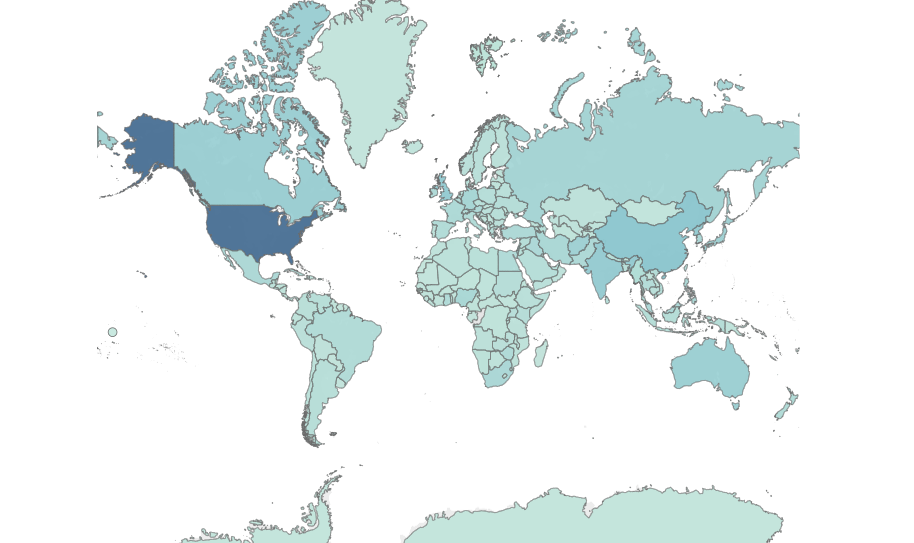

We observe the overwhelming dominance of the United States in this area, as well as the strong presence of countries such as China, India, Russia, Australia or Canada.

**Visualization Choice and Rationale**

Choropleth maps were selected to illustrate the geographic distribution of conflict activity, enabling users to quickly detect spatial patterns and cross-country differences. This visualization type is particularly effective for highlighting regions with higher concentrations of conflict events and observing how these patterns evolve over time. By encoding intensity through color gradients, the maps make cross-country comparisons intuitive while preserving essential geographic context.

The design is intentionally streamlined to emphasize macro-level spatial trends rather than operational detail. When combined with interactive filters—such as year or period selection, or conflict type, the choropleth maps function as a powerful exploratory tool. These interactions allow users to navigate seamlessly from a global overview to continent-level or country-specific perspectives, strengthening both interpretability and analytical depth.


**Next Steps : Deepening the Analysis of Media Coverage vs. Conflict Severity**

| Next Step | Method | Insights Provided | Value for Decision-Makers |
|-----------|--------|-----------------|--------------------------|
| **1. Identify Structural Drivers Behind the Coverage–Severity Mismatch** | - Model media attention using regression or feature-importance analysis (e.g., GLM, Random Forest).<br>- Include variables capturing:<br>  • Region, geopolitical blocs, or proximity to major media centers<br>  • Conflict type (COERCE, FIGHT, ASSAULT, UVMV)<br>  • Event volume characteristics (SumEvents, TotalEvents)<br>  • Country-level attributes (population size, economic influence, regime type) | - Pinpoint which factors systematically overshadow severity in shaping visibility.<br>- Distinguish structural media biases (regional, political, economic) from data-driven effects (volume).<br>- Clarify how much severity “matters” once structural variables are controlled. | - Supports evidence-based advocacy highlighting why severe conflicts remain invisible.<br>- Helps predict under-covered crises based on structural features, not just intensity. |
| **2. Build a Severity-Adjusted Media Attention Index** | - Construct an index comparing observed media coverage to expected coverage based on conflict severity and event volume.<br>- Use residual analysis: coverage residuals from a model predicting attention from severity + volume.<br>- Standardize residuals to identify over- and under-exposure patterns. | - Identifies countries/regions with systematic under-attention, controlling for objective conflict intensity.<br>- Reveals cases where media exposure is disproportionately high relative to severity.<br>- Produces a comparable metric across space and time. | - Provides a simple, communicable indicator for prioritizing “silent crises.”<br>- Helps organizations track progress in reducing attention gaps. |
| **3. Compare Media Coverage with Ground-Reality Indicators from External Sources** | - Cross-check media visibility with widely used external conflict and humanitarian indicators such as:<br>  • ACLED severity measures: number and type of violent events recorded by field-based monitors.<br>  • UCDP fatality estimates: annual estimates of conflict-related deaths.<br>  • Humanitarian impact indicators: numbers of IDPs, refugees, or crisis severity scores used by agencies. | - Validates whether severity under-coverage persists across multiple data sources.<br>- Reveals whether media patterns reflect reporting biases or dataset-specific limitations.<br>- Strengthens confidence in identifying genuine “disconnect zones.” | - Provides a robust multi-source foundation for operational prioritization.<br>- Helps humanitarian actors build stronger cases for intervention or funding in overlooked areas. |


## 3.4-Countries Most Affected by Severe Conflicts

Overall, the analysis of severe conflict events highlights that extreme violence is **unevenly distributed across countries and regions**. While some countries experience a high number of events relative to their population, others face fewer events but of far greater severity. Certain regions, such as the Middle East and Central America, consistently exhibit a higher prevalence of severe conflict types, whereas other areas show mixed patterns. These findings underscore the importance of considering both **event frequency and intensity** when identifying global conflict hotspots and prioritizing interventions.

**Bar Chart - Total Number of Events in the USA with Severity Score <= 9 on the Goldstein Scale**

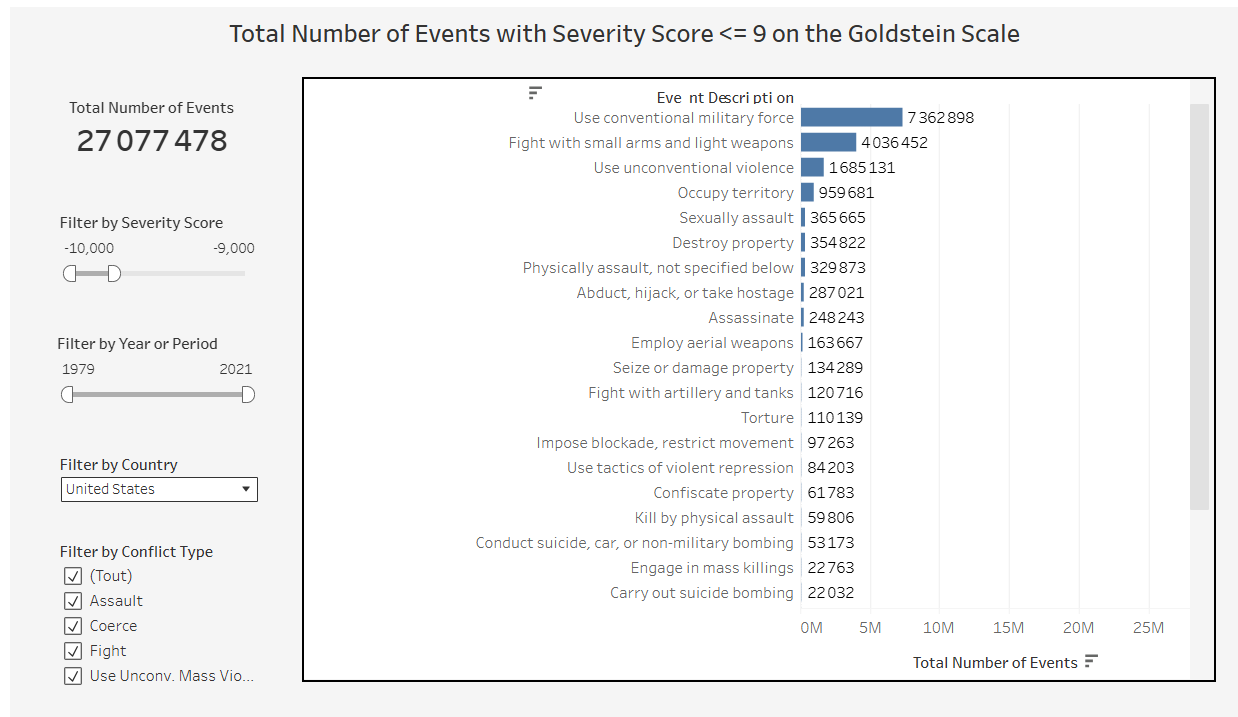

**Visualization Choice and Rationale**

A bar chart was selected to represent the total number of events for each event description, specifically focusing on events with **Goldstein Scale values between -9 and -10** to highlight the most severe conflicts. This visualization allows for quick identification of which types of events contribute most to extreme conflict intensity. By encoding event counts as bar heights and enabling filters by **Goldstein Scale severity and country**, the chart provides a flexible and interactive way to explore both global patterns and country-specific dynamics.

**Next Steps: Deepening the Analysis of Severe Conflict Events**

| Next Step | Method | Insights Provided | Value for Decision-Makers |
|-----------|--------|-----------------|--------------------------|
| **1. Cross-Analyze Extreme Event Distribution and Temporal Patterns** | - Focus on events with Goldstein ≤ -9. <br>- Combine with country-level normalized conflict intensity. <br>- Construct time series at country and regional levels to detect escalation periods, peaks, and trend shifts. <br>- Filter by event type and region. | - Identifies countries/regions experiencing the most extreme events relative to population. <br>- Highlights underreported high-severity hotspots. <br>- Differentiates chronic high-intensity countries from episodic crises. <br>- Reveals timing of exceptional conflict surges. | - Supports prioritization of monitoring and verification for extreme conflicts. <br>- Guides allocation of analytical and humanitarian resources. <br>- Enables early warning and targeted response planning. |
| **2. Characterize Event Type Contribution to Extreme Severity** | - Classify Goldstein ≤ -9 events by event description. <br>- Quantify each type’s contribution per country/region. | - Shows which conflict types drive extreme severity locally. <br>- Highlights patterns not visible from total counts. | - Supports targeted intervention strategies and detailed risk assessments. |
| **3. Identify and Analyze Extreme Event Outliers** | - Detect outliers among Goldstein ≤ -9 events using statistical thresholds (z-scores, IQR). <br>- Examine spatial, temporal, and typological characteristics of outliers. | - Reveals rare but exceptionally severe incidents. <br>- Helps distinguish typical high-severity events from anomalies. | - Informs refined prioritization and high-resolution monitoring. |


## 3.5-Actionable Insights from Exploratory Analysis

Although preliminary, the analysis conducted in this notebook highlights meaningful patterns in conflict intensity and media visibility across countries and regions. Based on the current dataset and visualizations, the following operational actions can be implemented immediately:

**1-Prioritize Countries Showing High Normalized Conflict Intensity but Low Media Visibility**

- NormalizedEvents1000 varies strongly across countries.  
- Correlations show that severity does *not* predict coverage.  
- Some regions receive significantly more or less media attention (ANOVA + Games–Howell).  
→ This combination statistically identifies *underreported but high-burden countries*.

**Operational implications:**  
- Establish a **priority monitoring list** for countries where conflict intensity is high yet media coverage is systematically low.  
- Strengthen local reporting partnerships, or satellite monitoring where media attention is not a reliable proxy for crisis burden.

---

**2-Use Regional Differentiation in Media Coverage to Guide Advocacy Strategies**

- Welch ANOVA shows significant regional differences in average media coverage.  
- Post-hoc tests identify specific regions that systematically differ.

**Operational implications:**  
- Target **communication and advocacy strategies** toward regions identified as statistically under-covered (to assess whether these regions are actually experiencing more severe conflict, these media-coverage patterns need to be cross-checked with additional empirical variables).  
- Inform donors and institutions that media visibility is biased by regional patterns rather than conflict intensity.

---

**3-Exploit Spatial Clustering of Conflict Intensity to Inform Regional Planning**

- Choropleth maps reveal clear geographic clustering in conflict intensity.  
- This is a visual but data-driven observation on spatial distribution.
  
**Operational implications:**  
- Use these clusters to inform **regional planning**, notably in:  
  - diplomatic engagement,  
  - humanitarian supply chain routing,  
  - cross-border coordination.  
- Focus regional efforts where high-intensity countries are geographically contiguous.

---

**4-Use Spatial Variation to Identify Regions Requiring Different Types of Monitoring**

- Regions differ significantly in event volume and media coverage.  
- No region breaks the severity–coverage pattern.

**Operational implications:**  
- Regions with high intensity but low coverage require **enhanced analytical monitoring**.  
- Regions with high visibility but moderate intensity require **bias correction** in perception and resource allocation.

## 3.6-Next Steps and Concluding Remarks

The actions derived from this exploratory analysis, such as monitoring high-intensity conflict zones that are under-reported in the media and addressing regional media biases, should be systematically integrated into the organization’s operational workflows wherever possible. Each actionable initiative can be linked to specific responsibilities, assigning teams or individuals to implement, monitor, and report on these tasks.

It is also important to consider strategic alignment with organizational priorities and partners. Some actions may benefit from collaboration with external stakeholders to ensure that interventions are complementary and that insights feed into broader humanitarian or policy frameworks. Coordinating with partners can enhance reach, credibility, and effectiveness while avoiding duplication of effort.

A presentation for decision-makers should summarize key insights, suggested actions, assigned responsibilities, and potential analyses or modeling initiatives. The presentation should also include an evaluation of internal capacity, expected operational impact, and cost–benefit considerations for each proposed initiative. This structured approach enables the organization to prioritize initiatives that are feasible, high-impact, and aligned with both internal strategy and external partnerships.

Integrating actionable insights into operational workflows and strategic planning ensures that analyses translate into concrete, evidence-based decision-making. By clearly defining responsibilities, focusing on high-priority actions, and coordinating with partners, the organization can maximize operational effectiveness, respond promptly to emerging conflicts, and allocate resources where they are most needed. This approach strengthens the connection between data analysis, strategic alignment, and practical interventions, enhancing the overall capacity to make informed and coordinated decisions.

Moreover, by leveraging these insights, interventions in the field of peace and conflict management can become more targeted, timely, and effective. Understanding where high-intensity conflicts are under-reported, and how media attention is distributed, allows the organization to prioritize efforts in regions that need support most. This not only improves the efficiency of humanitarian and peacebuilding operations but also contributes to reducing suffering, preventing escalation, and supporting sustainable conflict resolution in the communities served.